# 2.8 Gaussian city with relocations

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from city_simulator import City

# Integration test (no figures saved)

2025-10-08 11:29:01,010 - INFO - Initializing city
2025-10-08 11:29:01,013 - INFO - Calculating density profile for 1 core(s)
2025-10-08 11:29:01,023 - INFO - Running simulation for 5000 steps
2025-10-08 11:29:03,868 - INFO - Simulation completed in 2.84 seconds
2025-10-08 11:29:03,869 - INFO - In-simulation time passed: 17 days
2025-10-08 11:29:03,870 - INFO - Overall, statistics gathered over: 7 days
2025-10-08 11:29:03,870 - INFO - Cumulative rentals happened: 13968
2025-10-08 11:29:03,870 - INFO - Average rentals per car per day: 4.02
2025-10-08 11:29:03,871 - INFO - Average rental time per trip, min: 17.75
2025-10-08 11:29:03,872 - INFO - Average CM1 gain per trip, Eur: 4.44
2025-10-08 11:29:03,872 - INFO - Overall CM2 profit per day, Eur: -1072.48
2025-10-08 11:29:03,873 - INFO - Average relocations per day: 0.00


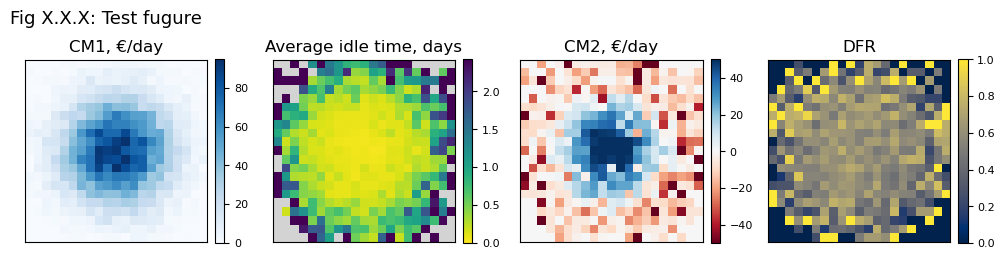

In [ ]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "p_factor": 0.15, # Bring the rentals/car/day to about 4-5
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
}

# To be able to re-run this one cell only, repeat package imports here
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize(plots=["cm1", "idle_times", "cm2", "dfr"], title="Fig X.X.X: Test fugure")

In [4]:
stop_here()  # Intentional crash against "run all" overwriting everything

NameError: name 'stop_here' is not defined

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-10-08 11:36:02,016 - INFO - Initializing city
2025-10-08 11:36:02,018 - INFO - Calculating density profile for 1 core(s)
2025-10-08 11:36:02,031 - INFO - Running simulation for 10000 steps
2025-10-08 11:36:05,838 - INFO - ..Simulating step 5000 of 10000
2025-10-08 11:36:13,695 - INFO - Simulation completed in 11.66 seconds
2025-10-08 11:36:13,697 - INFO - In-simulation time passed: 35 days
2025-10-08 11:36:13,698 - INFO - Overall, statistics gathered over: 24 days
2025-10-08 11:36:13,700 - INFO - Cumulative rentals happened: 67135
2025-10-08 11:36:13,702 - INFO - Average rentals per car per day: 5.52
2025-10-08 11:36:13,704 - INFO - Average rental time per trip, min: 17.54
2025-10-08 11:36:13,705 - INFO - Average CM1 gain per trip, Eur: 4.38
2025-10-08 11:36:13,706 - INFO - Overall CM2 profit per day, Eur: 2108.22
2025-10-08 11:36:13,708 - INFO - Average relocations per day: 0.00
2025-10-08 11:36:14,345 - INFO - Initializing city
2025-10-08 11:36:14,347 - INFO - Calculating densit

Creating a 2nd city now...


2025-10-08 11:36:29,846 - INFO - ..Simulating step 5000 of 10000
2025-10-08 11:36:34,543 - INFO - Simulation completed in 20.16 seconds
2025-10-08 11:36:34,544 - INFO - In-simulation time passed: 35 days
2025-10-08 11:36:34,548 - INFO - Overall, statistics gathered over: 24 days
2025-10-08 11:36:34,550 - INFO - Cumulative rentals happened: 67773
2025-10-08 11:36:34,551 - INFO - Average rentals per car per day: 5.58
2025-10-08 11:36:34,552 - INFO - Average rental time per trip, min: 17.55
2025-10-08 11:36:34,554 - INFO - Average CM1 gain per trip, Eur: 4.39
2025-10-08 11:36:34,556 - INFO - Overall CM2 profit per day, Eur: 2233.46
2025-10-08 11:36:34,559 - INFO - Average relocations per day: 3.21


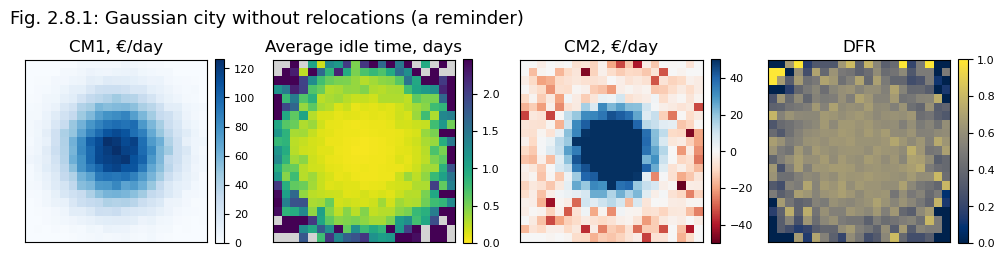

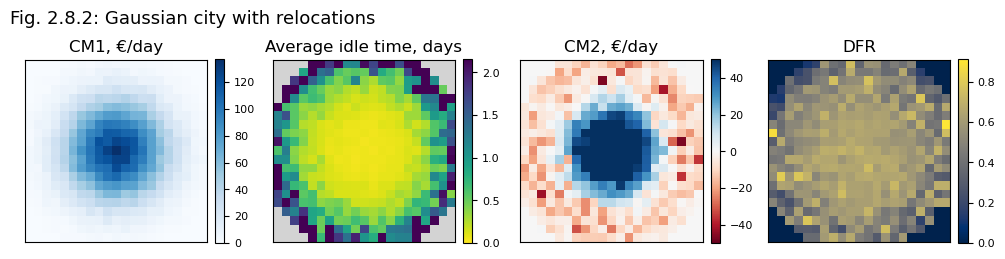

In [10]:
# Nice city
config = {
    "seed": 1,  # Random seed
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "n_cars": 500,
    "p_factor": 0.2, # Bring the rentals/car/day to about 4-5
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "do_flatten_demand": False,
    "do_relocations": False,
    "relo_cost": 20,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(10000)

plt.figure(figsize=(10, 5))
city.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.1: Gaussian city without relocations (a reminder)"
)
# plt.savefig("../figures/02relos_08city_01control.svg", dpi=300)

print("Creating a 2nd city now...")
config["do_relocations"] = True
city2 = City(config)
city2.init_cars()
city2.simulate(10000)

plt.figure(figsize=(10, 5))
city2.visualize(
    plots=["cm1", "idle_times", "cm2", "dfr"],
    title="Fig. 2.8.2: Gaussian city with relocations"
)
# plt.savefig("../figures/02relos_08city_02relocations.svg", dpi=300)

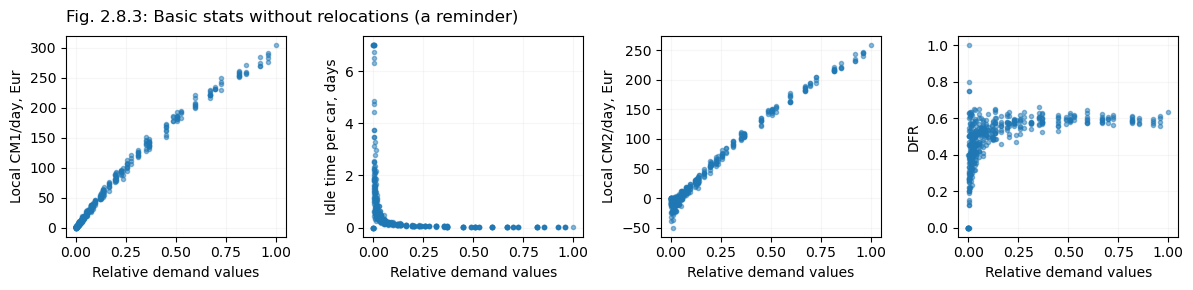

In [8]:
# Stats, use data from the previous run 👆

def simple_stats_figure(city, title):
    demand = city.demand.flatten()
    cm1 = city.map_cm1.flatten() / city.n_days
    cm2 = city.map_cm2.flatten() / city.n_days
    idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
    dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())

    plt.figure(figsize=(12, 3))
    plt.subplot(141)
    plt.title(title, loc='left', pad=10);
    plt.plot(demand, cm1, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM1/day, Eur")

    plt.subplot(142)
    plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Idle time per car, days")

    plt.subplot(143)
    plt.plot(demand, cm2, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("Local CM2/day, Eur")

    plt.subplot(144)
    plt.plot(demand, dfr, '.', alpha=0.5)
    plt.grid(alpha=0.1)
    plt.xlabel("Relative demand values")
    plt.ylabel("DFR")

    plt.tight_layout();

simple_stats_figure(city, "Fig. 2.8.3: Basic stats without relocations (a reminder)")
# plt.savefig("../figures/02relos_08city_03control_stats.svg", dpi=300)

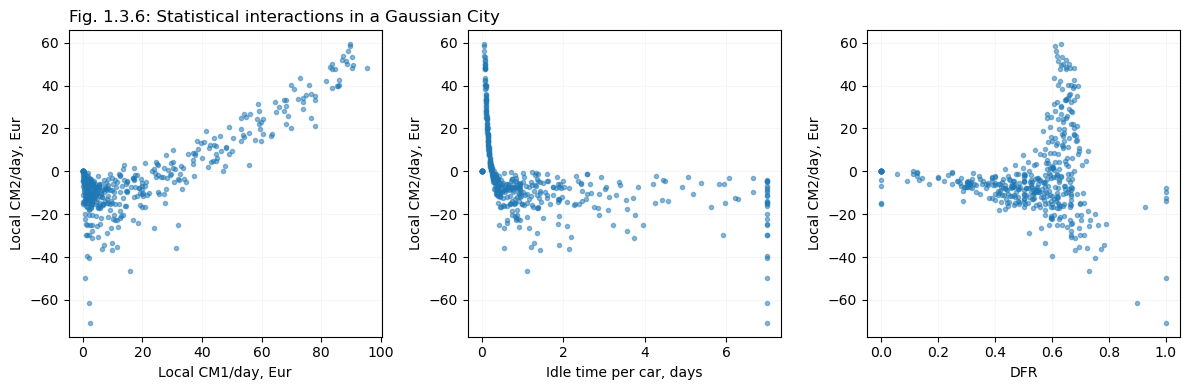

In [ ]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.6: Statistical interactions in a Gaussian City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
# plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)